# Action-Angle Coordinates: Staeckel Approximation

The Staeckel approximation (`actionAngleStaeckel`) is the most accurate general
method for computing actions in axisymmetric potentials. It works by locally
approximating the potential as a Staeckel potential (separable in confocal
ellipsoidal coordinates), following the algorithm of
[Binney (2012)](http://adsabs.harvard.edu/abs/2012MNRAS.426.1324B).

For all intents and purposes, the Staeckel approximation makes the
[adiabatic approximation](adiabatic.ipynb) obsolete: it is as fast and more precise. The only
additional requirement is that the user must specify a *focal length* $\Delta$, but this
can be easily estimated from the potential.

For an introduction to action-angle coordinates and simpler methods, see
the [Introduction](introduction.ipynb). For the orbit-integration-based method
that works for highly eccentric orbits, see [IsochroneApprox](isochroneapprox.ipynb).

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
from galpy.potential import MWPotential2014
from galpy.orbit import Orbit

## Setup

The key parameter is `delta`, the focus of the confocal coordinate system.
You can estimate an appropriate value using `estimateDeltaStaeckel`, which
estimates $\Delta$ from the second derivatives of the potential
(see [Sanders 2012](http://adsabs.harvard.edu/abs/2012MNRAS.426..128S)):

In [2]:
from galpy.actionAngle import actionAngleStaeckel, estimateDeltaStaeckel

# Estimate delta for an orbit near R=1, z=0
delta = estimateDeltaStaeckel(MWPotential2014, 1.0, 0.0)
print("Estimated delta:", delta)

Estimated delta: 0.7013326670567281


For more accuracy, you can estimate `delta` along an integrated orbit by
averaging (through the median) estimates at positions around the orbit:

In [3]:
o = Orbit([1.0, 0.1, 1.1, 0.0, 0.25, 0.0])
ts = numpy.linspace(0, 100, 1001)
o.integrate(ts, MWPotential2014)

# Estimate delta from the orbit's R and z range
delta_orbit = estimateDeltaStaeckel(MWPotential2014, o.R(ts), o.z(ts))
print("Delta from orbit:", delta_orbit)

Delta from orbit: 0.40272708628053305


We will use $\Delta = 0.4$ in what follows. We set up the
`actionAngleStaeckel` object with `c=True` to use the fast C implementation:

In [4]:
aAS = actionAngleStaeckel(pot=MWPotential2014, delta=0.4, c=True)

## Computing actions

Calling the object returns $(J_R, L_z, J_z)$:

In [5]:
jr, jphi, jz = aAS(1.0, 0.1, 1.1, 0.0, 0.05)
print(f"J_R = {jr.item():.6f}, L_z = {jphi.item():.6f}, J_z = {jz.item():.6f}")

J_R = 0.013636, L_z = 1.100000, J_z = 0.000463


For the orbit with higher vertical excursion:

In [6]:
jr_hz, jphi_hz, jz_hz = aAS(o.R(), o.vR(), o.vT(), o.z(), o.vz())
print(f"J_R = {jr_hz.item():.6f}, L_z = {jphi_hz.item():.6f}, J_z = {jz_hz.item():.6f}")

J_R = 0.019222, L_z = 1.100000, J_z = 0.015277


## Computing actions, frequencies, and angles

The `actionsFreqs` method returns $(J_R, L_z, J_z, \Omega_R, \Omega_\phi, \Omega_z)$:

In [7]:
jr, jphi, jz, Or, Op, Oz = aAS.actionsFreqs(1.0, 0.1, 1.1, 0.0, 0.05)
print(f"J_R = {jr.item():.6f}, L_z = {jphi.item():.6f}, J_z = {jz.item():.6f}")
print(
    f"Omega_R = {Or.item():.4f}, Omega_phi = {Op.item():.4f}, Omega_z = {Oz.item():.4f}"
)

J_R = 0.013636, L_z = 1.100000, J_z = 0.000463
Omega_R = 1.1595, Omega_phi = 0.8682, Omega_z = 2.1432


The `actionsFreqsAngles` method additionally returns the angles
$(\theta_R, \theta_\phi, \theta_z)$. Note that you **must** specify `phi`
for the angles:

In [8]:
jr, jphi, jz, Or, Op, Oz, wr, wp, wz = aAS.actionsFreqsAngles(
    1.0, 0.1, 1.1, 0.0, 0.05, 0.0
)
print(f"J_R = {jr.item():.6f}")
print(
    f"Omega_R = {Or.item():.4f}, Omega_phi = {Op.item():.4f}, Omega_z = {Oz.item():.4f}"
)
print(
    f"theta_R = {wr.item():.4f}, theta_phi = {wp.item():.4f}, theta_z = {wz.item():.4f}"
)

J_R = 0.013636
Omega_R = 1.1595, Omega_phi = 0.8682, Omega_z = 2.1432
theta_R = 0.4687, theta_phi = 6.1767, theta_z = 6.0535


<div class="alert alert-warning">

**Warning:** Frequencies and angles using the Staeckel approximation are
*only* implemented in C. You must use `c=True` in the setup of the
`actionAngleStaeckel` object.

</div>

<div class="alert alert-warning">

**Warning:** Angles using the Staeckel approximation in galpy follow this
convention: (a) the radial angle starts at zero at pericenter and increases
going toward apocenter; (b) the vertical angle starts at zero at $z=0$ and
increases toward positive $z_{\max}$. The latter is a **different convention**
from that in Binney (2012), but is consistent with `actionAngleIsochrone`
and `actionAngleSpherical`.

</div>

## Checking conservation of actions along an orbit

We can verify that the actions are conserved along the orbit with higher
vertical excursion (reaching about 1.35 kpc from the plane for $R_0 = 8$ kpc):

In [9]:
print(f"Maximum height: {o.zmax() * 8.0:.2f} kpc")

Maximum height: 1.35 kpc


Now plot the action conservation:

Text(0.5, 1.0, 'Staeckel: action conservation (high-z orbit)')

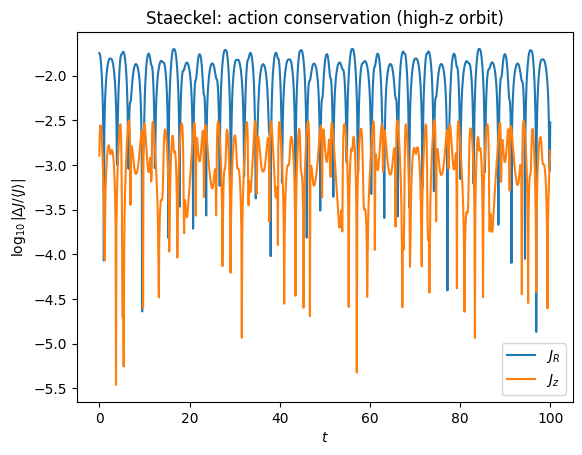

In [10]:
js = aAS(o.R(ts), o.vR(ts), o.vT(ts), o.z(ts), o.vz(ts))

plt.plot(ts, numpy.log10(numpy.fabs((js[0] - numpy.mean(js[0])) / numpy.mean(js[0]))))
plt.plot(ts, numpy.log10(numpy.fabs((js[2] - numpy.mean(js[2])) / numpy.mean(js[2]))))
plt.xlabel(r"$t$")
plt.ylabel(r"$\log_{10}|\Delta J / \langle J \rangle|$")
plt.legend([r"$J_R$", r"$J_z$"])
plt.title("Staeckel: action conservation (high-z orbit)")

The radial action is conserved to better than a percent and the vertical action
to only a fraction of a percent. This is much better than the five to ten
percent errors found with the adiabatic approximation for the same orbit.

## Checking that angles increase linearly

We can also verify that the angles increase linearly along the orbit:

Text(0.5, 1.0, 'Staeckel: angles vs. time')

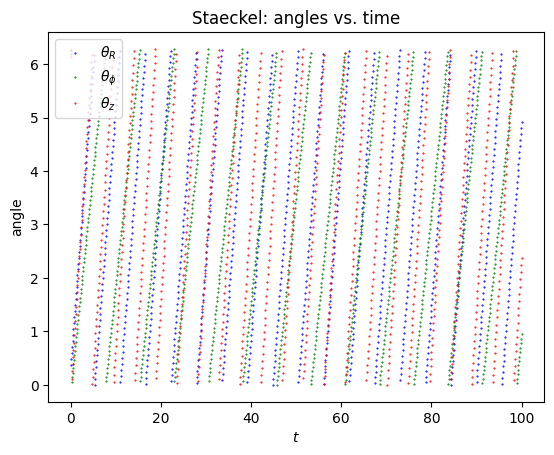

In [11]:
o2 = Orbit([1.0, 0.1, 1.1, 0.0, 0.25, 0.0])
o2.integrate(ts, MWPotential2014)

jfa = aAS.actionsFreqsAngles(
    o2.R(ts), o2.vR(ts), o2.vT(ts), o2.z(ts), o2.vz(ts), o2.phi(ts)
)

plt.plot(ts, jfa[6], "b.", ms=1)
plt.plot(ts, jfa[7], "g.", ms=1)
plt.plot(ts, jfa[8], "r.", ms=1)
plt.xlabel(r"$t$")
plt.ylabel(r"angle")
plt.legend([r"$\theta_R$", r"$\theta_\phi$", r"$\theta_z$"])
plt.title("Staeckel: angles vs. time")

We can also look at the angle-angle plane:

Text(0.5, 1.0, '$\\theta_R$ vs. $\\theta_z$')

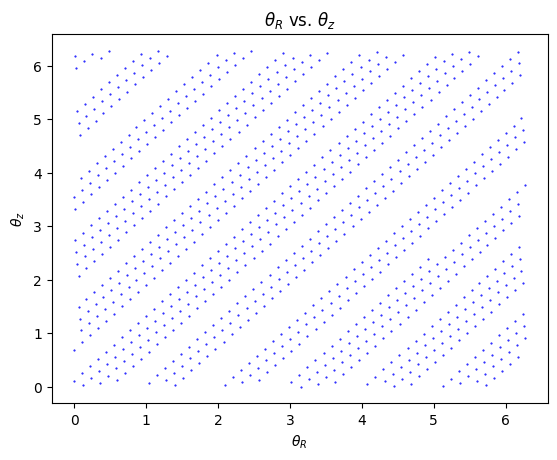

In [12]:
plt.plot(jfa[6], jfa[8], "b.", ms=1)
plt.xlabel(r"$\theta_R$")
plt.ylabel(r"$\theta_z$")
plt.title(r"$\theta_R$ vs. $\theta_z$")

## Grid-based interpolation: actionAngleStaeckelGrid

For applications requiring many evaluations (e.g., distribution functions),
you can set up a grid-based interpolation that precomputes actions on a grid
and interpolates. Because this is a fully three-dimensional grid, setting up
the grid takes longer than for the adiabatic method, but evaluations are
significantly faster afterwards:

In [13]:
from galpy.actionAngle import actionAngleStaeckelGrid

aASG = actionAngleStaeckelGrid(
    pot=MWPotential2014, delta=0.4, c=True, nE=51, npsi=51, nLz=61
)

Compare the grid-based and direct calculations:

In [14]:
# Same interface as actionAngleStaeckel
jr_direct, _, jz_direct = aAS(o.R(), o.vR(), o.vT(), o.z(), o.vz())
jr_grid, _, jz_grid = aASG(o.R(), o.vR(), o.vT(), o.z(), o.vz())

print(f"J_R: direct = {jr_direct.item():.6f}, grid = {jr_grid.item():.6f}")
print(f"J_z: direct = {jz_direct.item():.6f}, grid = {jz_grid.item():.6f}")

J_R: direct = 0.019222, grid = 0.019221
J_z: direct = 0.015277, grid = 0.015023


The grid-based interpolation gives a significant speed-up over even the
direct C implementation (up to about 25 times for large arrays).
The speed-up is especially significant for complex potentials like
`MWPotential2014`.

## Speed-up with C and fixed_quad

The `actionAngleStaeckel` calculations can be sped up in two ways:

1. Using Gaussian quadrature with `fixed_quad=True` (about 10x speed-up)
2. Using the C implementation with `c=True` (additional 15x speed-up for arrays)

For `MWPotential2014`, the overall speed-up from Python without `fixed_quad`
to C is very significant, and the grid-based version is faster still.